# 03 — MHC-I Binding Prediction

This notebook runs MHCflurry's `Class1PresentationPredictor` on peptides from one or two example HCC1395 mutations.

We compare:
- **Binding affinity (BA)**: predicted IC50 in nM (lower = tighter binding)
- **Presentation score (PS)**: combined BA + antigen processing score

We also compute **agretopicity** = WT affinity / mutant affinity.

> **Setup**: Before running this notebook, install MHCflurry and its dependencies:
> ```bash
> pip install mhcflurry 'setuptools<71'
> mhcflurry-downloads fetch
> ```
> `setuptools<71` is required because MHCflurry depends on `pkg_resources`, which was removed in setuptools ≥ 71.

In [1]:
import sys
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.ticker as ticker
import seaborn as sns

# Add src to path if running from notebooks directory
sys.path.insert(0, str(Path("../src").resolve()))

from neoantigen_pipeline.io.vcf_reader import VCFReader
from neoantigen_pipeline.io.hla_reader import HLAReader
from neoantigen_pipeline.io.proteome import ProteomeDB
from neoantigen_pipeline.candidates.peptide_generator import PeptideGenerator
from neoantigen_pipeline.config import PeptideGenerationConfig, MHCIPredictionConfig
from neoantigen_pipeline.prediction.mhcflurry import MHCflurryPredictor
from neoantigen_pipeline.scoring.agretopicity import AgretopicityScorer

sns.set_style("whitegrid")
plt.rcParams["font.size"] = 12
plt.rcParams["figure.figsize"] = (10, 6)

print("Imports OK")

Imports OK


In [2]:
# Define paths
DATA_DIR      = Path("../data/HCC1395_inputs")
VCF_PATH      = DATA_DIR / "annotated.expression.vcf.gz"
HLA_PATH      = DATA_DIR / "optitype_normal_result.tsv"
PROTEOME_PATH = DATA_DIR / "Homo_sapiens.GRCh38.pep.all.fa.gz"

# Load HLA
hla_reader = HLAReader()
hla = hla_reader.read_optitype(str(HLA_PATH))
print(f"HLA class-I alleles: {hla.class_i_alleles}")

# Load variants
print("\nLoading variants ...")
variants = VCFReader(str(VCF_PATH)).read_missense_variants()
print(f"  {len(variants)} missense variants loaded")

# Load proteome
print("Loading proteome ...")
proteome = ProteomeDB(str(PROTEOME_PATH))

# Build predictor (MHCflurryPredictor is the concrete MHC-I implementation)
mhci_config = MHCIPredictionConfig(alleles=tuple(hla.class_i_alleles))
predictor   = MHCflurryPredictor(mhci_config)
print(f"\nMHCIPredictionConfig alleles: {mhci_config.alleles}")

HLA class-I alleles: ('HLA-A*29:02', 'HLA-B*45:01', 'HLA-B*82:02', 'HLA-C*06:02')

Loading variants ...
  1133 missense variants loaded
Loading proteome ...

MHCIPredictionConfig alleles: ('HLA-A*29:02', 'HLA-B*45:01', 'HLA-B*82:02', 'HLA-C*06:02')


## Selecting Example Variants

In [3]:
# Pick 2 missense variants with valid proteome transcripts
pep_config = PeptideGenerationConfig()
generator  = PeptideGenerator(pep_config, proteome)

example_variants = []
for v in variants:
    if len(example_variants) >= 2:
        break
    if proteome.get_sequence(v.transcript_id) is not None:
        example_variants.append(v)

print(f"Selected {len(example_variants)} example variants:")
for v in example_variants:
    print(f"  {v.gene}  {v.protein_change}  (transcript={v.transcript_id})")

# Generate all peptide candidates for the two variants
all_candidates = []
for v in example_variants:
    cands = generator.generate(v)
    all_candidates.extend(cands)
    print(f"  {v.gene} {v.protein_change}: {len(cands)} peptide candidates")

print(f"\nTotal peptide candidates for prediction: {len(all_candidates)}")

Selected 2 example variants:
  OR4F16  p.Pro58Ala  (transcript=ENST00000332831.5)
  PRAMEF15  p.Arg96His  (transcript=ENST00000376152.2)
  OR4F16 p.Pro58Ala: 38 peptide candidates
  PRAMEF15 p.Arg96His: 38 peptide candidates

Total peptide candidates for prediction: 76


## Running MHCflurry Predictions

MHCflurry's `Class1PresentationPredictor` is used via the `MHCIPredictor` wrapper.  
It returns binding affinity (IC50 nM) and a presentation score for each peptide × allele combination.

In [4]:
from neoantigen_pipeline.results.cache import PredictionCache

cache = PredictionCache("../results/cache")
alleles = list(hla.class_i_alleles)
mf_mut_key = cache.make_key("mhcflurry_mutant", len(all_candidates), alleles)
results_df = cache.get(mf_mut_key)

if results_df is None:
    print("Running MHCflurry predictions (mutant peptides, results will be cached)...")
    mutant_results = predictor.predict_with_processing(all_candidates, alleles)
    print(f"Prediction results: {len(mutant_results)} candidates")
    results_df = pd.DataFrame([
        {
            "peptide":               r.peptide,
            "gene":                  r.gene,
            "mutation_str":          r.mutation_str,
            "best_allele":           r.best_allele,
            "affinity_nm":           r.affinity_nm,
            "affinity_percentile":   r.affinity_percentile,
            "processing_score":      r.processing_score,
            "presentation_score":    r.presentation_score,
            "n_flank":               r.n_flank,
            "c_flank":               r.c_flank,
        }
        for r in mutant_results
    ])
    cache.put(mf_mut_key, results_df)
    print(f"Cached {len(results_df)} MHCflurry mutant results")
else:
    print(f"Loaded {len(results_df)} cached MHCflurry mutant results")

print(f"DataFrame shape: {results_df.shape}")
print(f"Columns: {list(results_df.columns)}")
print("\nFirst 10 rows:")
display(results_df.head(10))


Loaded 76 cached MHCflurry mutant results
DataFrame shape: (76, 10)
Columns: ['peptide', 'gene', 'mutation_str', 'best_allele', 'affinity_nm', 'affinity_percentile', 'processing_score', 'presentation_score', 'n_flank', 'c_flank']

First 10 rows:


,peptide,gene,mutation_str,best_allele,affinity_nm,affinity_percentile,processing_score,presentation_score,n_flank,c_flank
0,TDPHLHSA,OR4F16,OR4F16_p.Pro58Ala,HLA-B*45:01,4876.111818,0.0,0.054409,0.020082,GNILIVFSVT,MYFLLASLSF
1,DPHLHSAM,OR4F16,OR4F16_p.Pro58Ala,HLA-B*82:02,5452.019588,0.0,0.259271,0.038518,NILIVFSVTT,YFLLASLSFI
2,PHLHSAMY,OR4F16,OR4F16_p.Pro58Ala,HLA-A*29:02,16322.807218,0.0,0.035245,0.005841,ILIVFSVTTD,FLLASLSFID
3,HLHSAMYF,OR4F16,OR4F16_p.Pro58Ala,HLA-A*29:02,7166.771420,0.0,0.078370,0.015195,LIVFSVTTDP,LLASLSFIDL
4,LHSAMYFL,OR4F16,OR4F16_p.Pro58Ala,HLA-C*06:02,20486.857352,0.0,0.010085,0.004261,IVFSVTTDPH,LASLSFIDLG
5,HSAMYFLL,OR4F16,OR4F16_p.Pro58Ala,HLA-C*06:02,9889.231050,0.0,0.051910,0.010094,VFSVTTDPHL,ASLSFIDLGA
6,SAMYFLLA,OR4F16,OR4F16_p.Pro58Ala,HLA-C*06:02,25310.983298,0.0,0.151408,0.005926,FSVTTDPHLH,SLSFIDLGAC
7,AMYFLLAS,OR4F16,OR4F16_p.Pro58Ala,HLA-C*06:02,29851.307820,0.0,0.018698,0.003056,SVTTDPHLHS,LSFIDLGACS
8,TTDPHLHSA,OR4F16,OR4F16_p.Pro58Ala,HLA-C*06:02,872.923546,0.0,0.417161,0.302956,TGNILIVFSV,MYFLLASLSF
9,TDPHLHSAM,OR4F16,OR4F16_p.Pro58Ala,HLA-C*06:02,2212.865673,0.0,0.017543,0.037022,GNILIVFSVT,YFLLASLSFI


In [5]:
mf_wt_key = cache.make_key("mhcflurry_wildtype", len(all_candidates), alleles)
wt_df = cache.get(mf_wt_key)

if wt_df is None:
    print("Running MHCflurry predictions (wildtype peptides, results will be cached)...")
    wt_results = predictor.predict_wildtype(all_candidates, alleles)
    print(f"Wildtype results: {len(wt_results)} candidates")
    wt_df = pd.DataFrame([
        {
            "mut_peptide":          r.mut_peptide,
            "wt_peptide":           r.wt_peptide,
            "wildtype_affinity_nm": r.wildtype_affinity_nm,
        }
        for r in wt_results
    ])
    cache.put(mf_wt_key, wt_df)
    print(f"Cached {len(wt_df)} MHCflurry wildtype results")
else:
    print(f"Loaded {len(wt_df)} cached MHCflurry wildtype results")

print(f"DataFrame shape: {wt_df.shape}")
print("\nFirst 10 rows:")
display(wt_df.head(10))


Loaded 76 cached MHCflurry wildtype results
DataFrame shape: (76, 3)

First 10 rows:


,mut_peptide,wt_peptide,wildtype_affinity_nm
0,TDPHLHSA,TDPHLHSP,12628.076633
1,DPHLHSAM,DPHLHSPM,8766.522633
2,PHLHSAMY,PHLHSPMY,17202.740385
3,HLHSAMYF,HLHSPMYF,3033.604214
4,LHSAMYFL,LHSPMYFL,11469.028156
5,HSAMYFLL,HSPMYFLL,3308.468202
6,SAMYFLLA,SPMYFLLA,20813.877970
7,AMYFLLAS,PMYFLLAS,30940.752797
8,TTDPHLHSA,TTDPHLHSP,4705.195319
9,TDPHLHSAM,TDPHLHSPM,4540.703564


## Binding Affinity vs Presentation Score

Using columns: affinity=affinity_nm, presentation=presentation_score, allele=best_allele


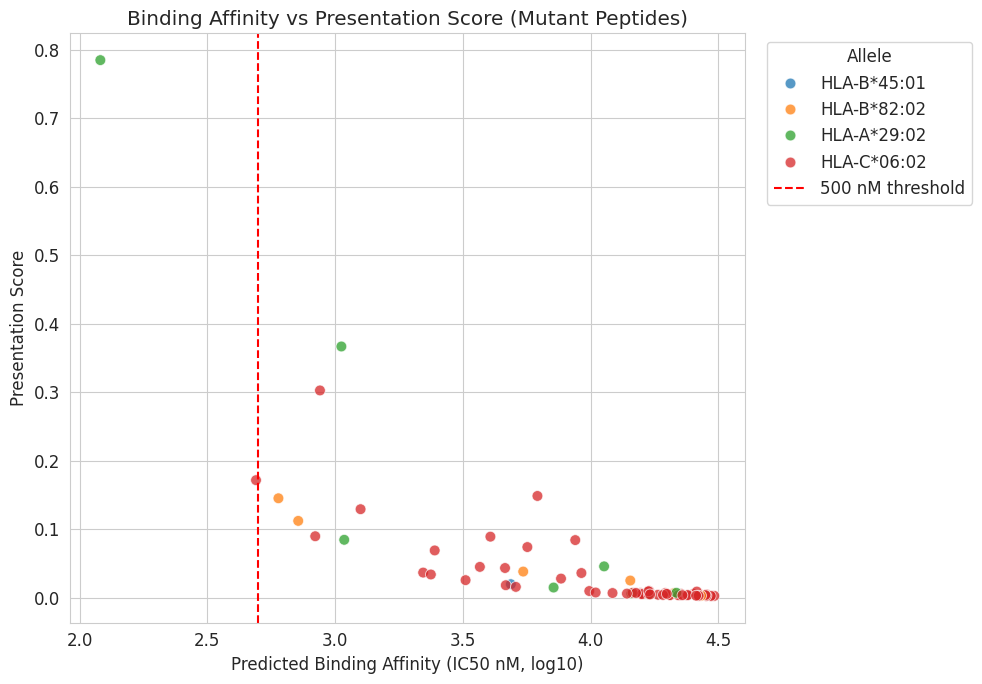

In [6]:
# Scatter: log10(affinity) vs presentation score, coloured by allele
plot_df = results_df.copy()

# Identify column names (may vary depending on pipeline implementation)
affinity_col     = next((c for c in plot_df.columns if "affinity" in c.lower()), None)
presentation_col = next((c for c in plot_df.columns if "presentation" in c.lower()), None)
allele_col       = next((c for c in plot_df.columns if "allele" in c.lower()), None)

print(f"Using columns: affinity={affinity_col}, presentation={presentation_col}, allele={allele_col}")

if affinity_col and presentation_col:
    plot_df = plot_df.dropna(subset=[affinity_col, presentation_col])
    plot_df["log10_affinity"] = np.log10(plot_df[affinity_col].clip(lower=1))

    fig, ax = plt.subplots(figsize=(10, 7))
    hue_col = allele_col if allele_col else None
    sns.scatterplot(data=plot_df, x="log10_affinity", y=presentation_col,
                    hue=hue_col, palette="tab10", alpha=0.75, s=60, ax=ax)
    ax.axvline(np.log10(500), color="red", linestyle="--", linewidth=1.5, label="500 nM threshold")
    ax.set_xlabel("Predicted Binding Affinity (IC50 nM, log10)")
    ax.set_ylabel("Presentation Score")
    ax.set_title("Binding Affinity vs Presentation Score (Mutant Peptides)")
    ax.legend(title="Allele", bbox_to_anchor=(1.02, 1), loc="upper left")
    plt.tight_layout()
    plt.show()
else:
    print("Could not identify affinity/presentation columns. Available:", list(plot_df.columns))

In [ ]:
# Distribution of presentation scores by allele — violin/box plot
if presentation_col and allele_col:
    fig, ax = plt.subplots(figsize=(12, 6))
    # hue= is required to avoid seaborn FutureWarning when using palette=
    sns.violinplot(data=plot_df, x=allele_col, y=presentation_col, hue=allele_col,
                   palette="tab10", inner="quartile", legend=False, ax=ax)
    ax.set_title("Presentation Score Distribution by HLA Allele")
    ax.set_xlabel("HLA Allele")
    ax.set_ylabel("Presentation Score")
    plt.xticks(rotation=30, ha="right")
    plt.tight_layout()
    plt.show()
else:
    print("Skipping violin plot — column names not identified.")

Processing score column: processing_score


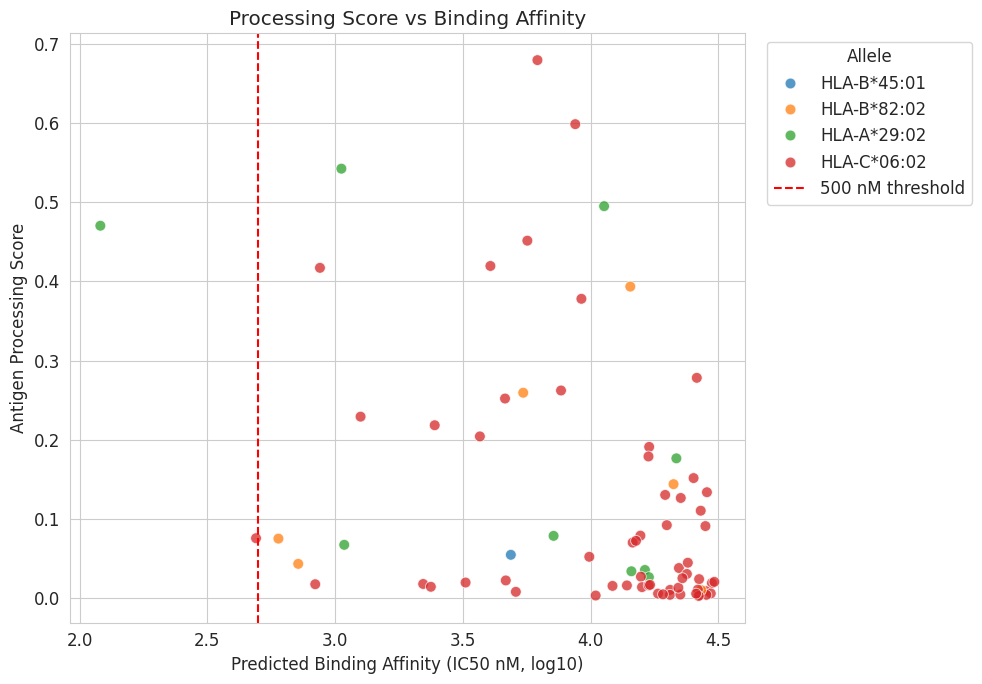

In [8]:
# Processing score vs affinity scatter
processing_col = next((c for c in results_df.columns if "processing" in c.lower()), None)
print(f"Processing score column: {processing_col}")

if affinity_col and processing_col:
    fig, ax = plt.subplots(figsize=(10, 7))
    sns.scatterplot(data=plot_df, x="log10_affinity", y=processing_col,
                    hue=allele_col, palette="tab10", alpha=0.75, s=60, ax=ax)
    ax.axvline(np.log10(500), color="red", linestyle="--", linewidth=1.5, label="500 nM threshold")
    ax.set_xlabel("Predicted Binding Affinity (IC50 nM, log10)")
    ax.set_ylabel("Antigen Processing Score")
    ax.set_title("Processing Score vs Binding Affinity")
    ax.legend(title="Allele", bbox_to_anchor=(1.02, 1), loc="upper left")
    plt.tight_layout()
    plt.show()
else:
    print("Processing score column not found. Available:", list(results_df.columns))

## Agretopicity

**Agretopicity** = (WT IC50) / (mutant IC50)

- Value > 1: mutant peptide binds MHC more tightly than WT → potentially immunogenic
- Value < 1: WT binds better → less likely to be a neoantigen

Merged shape: (76, 13)
Agretopicity > 1 (mutant binds better): 45


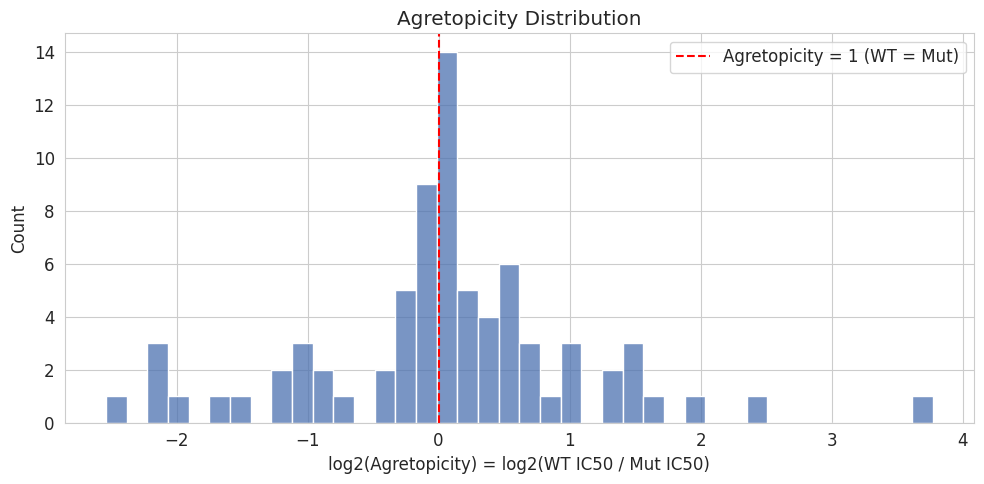


Top 5 candidates by agretopicity:


,peptide,gene,mutation_str,best_allele,affinity_nm,affinity_percentile,processing_score,presentation_score,n_flank,c_flank,wildtype_affinity_nm,wt_peptide,agretopicity
16,AMYFLLASL,OR4F16,OR4F16_p.Pro58Ala,HLA-C*06:02,836.598078,0.0,0.017204,0.090078,SVTTDPHLHS,SFIDLGACSV,11417.334788,PMYFLLASL,13.647336
8,TTDPHLHSA,OR4F16,OR4F16_p.Pro58Ala,HLA-C*06:02,872.923546,0.0,0.417161,0.302956,TGNILIVFSV,MYFLLASLSF,4705.195319,TTDPHLHSP,5.390157
52,GVHPRRWKL,PRAMEF15,PRAMEF15_p.Arg96His,HLA-C*06:02,490.644407,0.0,0.075408,0.171964,LDGLDALLTQ,QVLDLQDVCE,1901.516213,GVRPRRWKL,3.875549
18,TTDPHLHSAM,OR4F16,OR4F16_p.Pro58Ala,HLA-C*06:02,1258.677765,0.0,0.229062,0.129562,TGNILIVFSV,YFLLASLSFI,4070.470660,TTDPHLHSPM,3.233926
41,TQGVHPRR,PRAMEF15,PRAMEF15_p.Arg96His,HLA-C*06:02,3688.795209,0.0,0.204068,0.045354,AVLDGLDALL,WKLQVLDLQD,10509.339076,TQGVRPRR,2.848990


In [9]:
# Compute agretopicity using the AgretopicityScorer.
# mutant and wildtype DataFrames are index-matched (same order), so values
# can be pulled directly — no merge needed.
agreto_scorer = AgretopicityScorer()
agretopicities = agreto_scorer.compute_batch(
    results_df["affinity_nm"].tolist(),
    wt_df["wildtype_affinity_nm"].tolist(),
)

# Assemble a merged DataFrame for visualisation
merged = results_df.copy()
merged["wildtype_affinity_nm"] = wt_df["wildtype_affinity_nm"].values
merged["wt_peptide"]           = wt_df["wt_peptide"].values
merged["agretopicity"]         = agretopicities

print(f"Merged shape: {merged.shape}")
print(f"Agretopicity > 1 (mutant binds better): {(merged['agretopicity'] > 1).sum()}")

# Distribution of agretopicity
fig, ax = plt.subplots(figsize=(10, 5))
sns.histplot(np.log2(merged["agretopicity"].clip(lower=0.01)), bins=40, color="#4C72B0", ax=ax)
ax.axvline(0, color="red", linestyle="--", linewidth=1.5, label="Agretopicity = 1 (WT = Mut)")
ax.set_xlabel("log2(Agretopicity) = log2(WT IC50 / Mut IC50)")
ax.set_ylabel("Count")
ax.set_title("Agretopicity Distribution")
ax.legend()
plt.tight_layout()
plt.show()

print("\nTop 5 candidates by agretopicity:")
display(merged.nlargest(5, "agretopicity"))


### Weak-binding Agretopicity Artifacts

When both mutant **and** wildtype peptides bind poorly (IC50 > 5000 nM), the agretopicity
ratio becomes unreliable. A ratio of 2.0 when both affinities are >10,000 nM carries no
biological meaning — neither peptide is expected to be presented. These cases are flagged
below and marked distinctly in the scatter plot.

In [ ]:
# Flag weak-binding agretopicity artifacts (both mutant AND wildtype > 5000 nM)
weak_mask = (merged["affinity_nm"] > 5000) & (merged["wildtype_affinity_nm"] > 5000)
print(f"Weak-binding agretopicity artifacts: {weak_mask.sum()} / {len(merged)}")
print("  (Both mutant and wildtype IC50 > 5000 nM — ratio is biologically meaningless)")
merged["weak_binding"] = weak_mask
if weak_mask.any():
    display(merged[weak_mask][["peptide", "wt_peptide", "best_allele",
                               "affinity_nm", "wildtype_affinity_nm", "agretopicity"]].head(10))

In [ ]:
# Scatter: agretopicity vs presentation score, weak-binding artifacts marked distinctly
if "agretopicity" in merged.columns and "presentation_score" in merged.columns:
    plot_df = merged.dropna(subset=["presentation_score", "agretopicity"]).copy()
    plot_df["log2_agreto"] = np.log2(plot_df["agretopicity"].clip(lower=0.01))
    strong = plot_df[~plot_df["weak_binding"]]
    weak   = plot_df[plot_df["weak_binding"]]

    fig, ax = plt.subplots(figsize=(10, 7))
    sns.scatterplot(
        data=strong, x="presentation_score",
        y="log2_agreto", hue="best_allele",
        palette="tab10", alpha=0.75, s=70, ax=ax
    )
    # Weak-binding artifacts: hollow gray circles
    ax.scatter(
        weak["presentation_score"],
        weak["log2_agreto"],
        s=60, facecolors="none", edgecolors="gray", linewidths=1.2,
        label="Weak-binding artifact\n(both IC50 > 5000 nM)", zorder=3
    )
    ax.axhline(0, color="red", linestyle="--", linewidth=1.5, label="Agretopicity = 1")
    ax.set_xlabel("Presentation Score")
    ax.set_ylabel("log2(Agretopicity)")
    ax.set_title("Agretopicity vs Presentation Score\n(hollow = weak-binding artifact)")
    ax.legend(title="Allele", bbox_to_anchor=(1.02, 1), loc="upper left")
    plt.tight_layout()
    plt.show()
else:
    print("Agretopicity not computed — skipping final scatter.")